# scikit-learn Bootcamp — W1, Day 10
```
##### Preprocessing & Feature Engineering
##### StandardScaler · MinMaxScaler · RobustScaler · OHE · OrdinalEncoder · SimpleImputer · FunctionTransformer
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Q1 — EDA: missing value heatmap, dtype audit, cardinality check
##### Q2 — Scaling: StandardScaler vs MinMaxScaler vs RobustScaler
##### Q3 — Encoding: OHE vs OrdinalEncoder — what breaks with nominal categories
##### Q4 — Imputation: SimpleImputer vs KNNImputer
##### Q5 — Feature engineering: log transforms, cyclical encoding, interactions
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,RandomizedSearchCV,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,f1_score,classification_report
from scipy.stats import randint,uniform
import warnings;warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid');import numpy as np;np.random.seed(420)
from sklearn.preprocessing import MinMaxScaler,RobustScaler,FunctionTransformer
from sklearn.inspection import permutation_importance

---
### Dataset — HealthLine Article Dataset with Mixed Types (Synthetic)
```
# 4,000 articles. Features: numeric + categorical + missing values.
# This dataset is deliberately messy — requires real preprocessing.
```

In [2]:
np.random.seed(420)
n=4000
word_count    =np.random.lognormal(6.8,0.6,n).clip(200,5000).astype(int)
readability   =np.random.normal(65,12,n).clip(20,100).round(1)
publish_hour  =np.random.choice(range(24),n)
images_count  =np.random.poisson(3.2,n).clip(0,15)
author_followers=np.random.lognormal(8.5,1.2,n).clip(100,500000).astype(int)
days_since    =np.random.exponential(45,n).clip(1,365).astype(int)
category      =np.random.choice(['Health','Fitness','Nutrition','Mental Health'],n,p=[0.4,0.25,0.2,0.15])
quality_tier  =np.random.choice(['Low','Medium','High'],n,p=[0.3,0.5,0.2])
revenue_est   =np.random.lognormal(5,1.5,n).clip(10,50000).round(2)

# Inject missing values
miss_idx_read =np.random.choice(n,int(n*0.08),replace=False)
miss_idx_img  =np.random.choice(n,int(n*0.05),replace=False)
miss_idx_cat  =np.random.choice(n,int(n*0.03),replace=False)
readability[miss_idx_read]=np.nan
images_count=images_count.astype(float);images_count[miss_idx_img]=np.nan
cat_series=pd.Categorical(category)
cat_arr=np.array(category,dtype=object);cat_arr[miss_idx_cat]=np.nan

high_perf=(np.log1p(revenue_est)>np.percentile(np.log1p(revenue_est),75)).astype(int)

df=pd.DataFrame({'word_count':word_count,'readability':readability,'publish_hour':publish_hour,
    'images_count':images_count,'author_followers':author_followers,'days_since':days_since,
    'category':cat_arr,'quality_tier':quality_tier,'revenue_est':revenue_est,'high_performer':high_perf})

print(f'Shape: {df.shape}')
print(f'High performer rate: {high_perf.mean():.2%}')
print(df.dtypes)
display(df.head(6))

Shape: (4000, 10)
High performer rate: 25.00%
word_count            int64
readability         float64
publish_hour          int64
images_count        float64
author_followers      int64
days_since            int64
category             object
quality_tier         object
revenue_est         float64
high_performer        int64
dtype: object


,word_count,readability,publish_hour,images_count,author_followers,days_since,category,quality_tier,revenue_est,high_performer
0,670,NaN,13,3.0,1267,11,Nutrition,High,235.36,0
1,286,66.9,19,4.0,9236,6,Health,High,290.30,0
2,654,49.8,0,3.0,962,13,Nutrition,Low,59.20,0
3,743,57.0,10,4.0,4544,58,Nutrition,High,22.67,0
4,1094,63.0,15,3.0,1255,43,Fitness,High,27.19,0
5,1576,72.3,21,NaN,225,7,Nutrition,Medium,202.19,0


---
### Q1 — EDA: missing value audit, dtype inventory, cardinality
```
# (a) Missing value heatmap — where are the gaps?
# (b) Dtype and cardinality table for all columns.
# (c) Distribution of each numeric feature — skewness and outliers.
# (d) Based on the audit: design your ColumnTransformer architecture.
#     Which columns go to which branch?
```

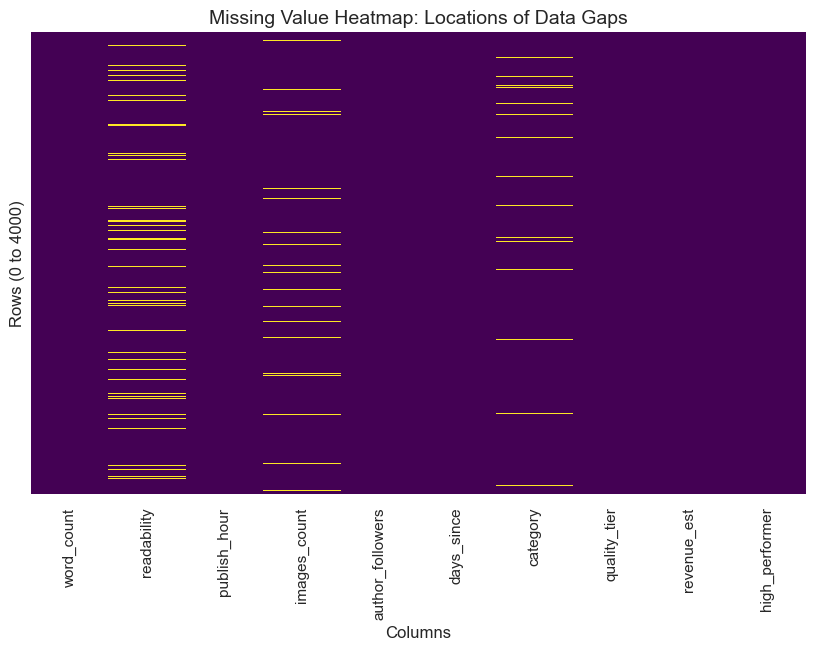

In [ ]:
# (a) Missing value heatmap — where are the gaps?

plt.figure(figsize=(10, 6))

# cbar=False removes the color scale legend
# yticklabels=False hides individual row numbers for readability
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Value Heatmap: Locations of Data Gaps', fontsize=14)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Rows (0 to 4000)', fontsize=12)
plt.show()

# The gaps (missing values) are located exclusively in three columns: readability, images_count, and category.
# note the NaN-as-category issue

In [ ]:
# (b) Dtype and cardinality table for all columns.

# Build a summary DataFrame for dtypes and cardinality
summary_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Cardinality': df.nunique(dropna=False), # Counts missing as a distinct state
    'Missing Values': df.isnull().sum()
})

# Display the final structured audit table
display(summary_df)

,Data Type,Cardinality,Missing Values
word_count,int64,1723,0
readability,float64,588,320
publish_hour,int64,24,0
images_count,float64,14,200
author_followers,int64,3534,0
days_since,int64,233,0
category,object,5,120
quality_tier,object,3,0
revenue_est,float64,3702,0
high_performer,int64,2,0


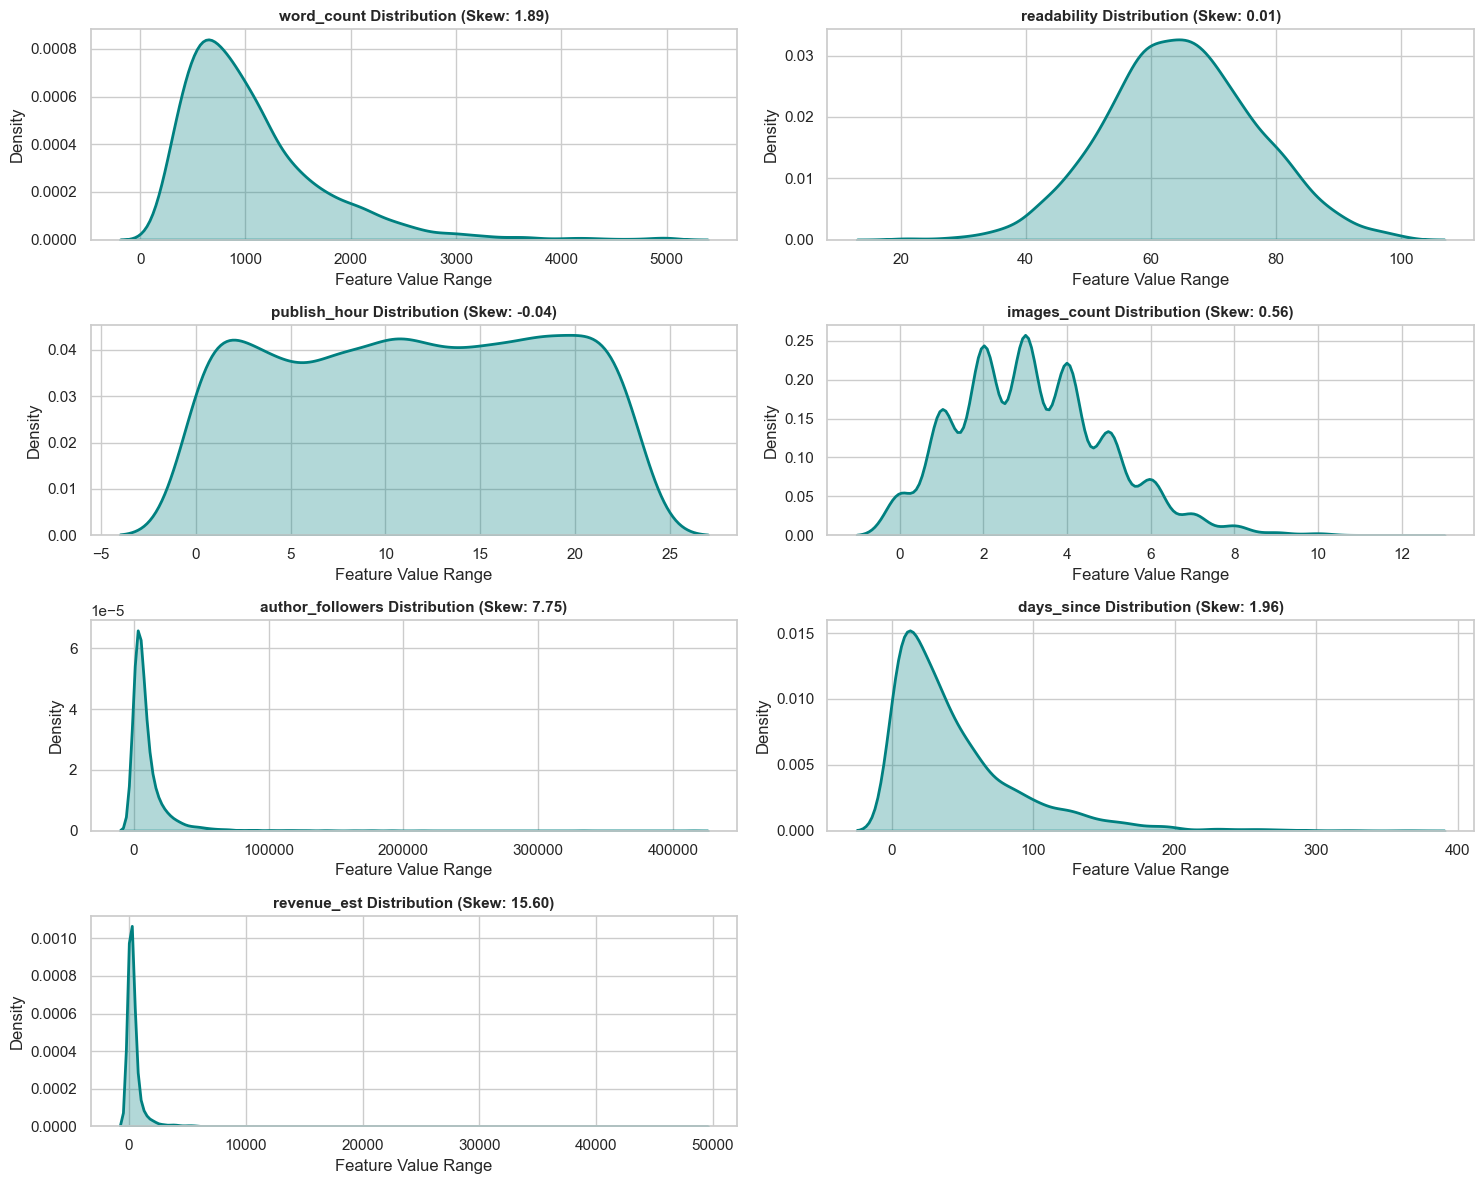

In [22]:
# (c) Distribution of each numeric feature — skewness and outliers.

import math

# 1. List the specific feature columns you want to visualize

features_to_plot = df.select_dtypes(include=[np.number]).columns.drop('high_performer').tolist()

# 2. Configure grid dimensions dynamically
n_cols = 2
n_rows = math.ceil(len(features_to_plot) / n_cols) # Automatically scales row count

# 3. Create the figure and subplots grid matrix
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 12))

# 4. Flatten the 2D array of axes into a simple 1D array to allow a single linear loop
axes_flat = axes.flatten()

# 5. Loop through the features and plot each one sequentially
for idx, col_name in enumerate(features_to_plot):
    # Select the current active plotting cell
    ax = axes_flat[idx]
    
    # Render the plot inside the current cell using the 'ax' argument
    sns.kdeplot(
    data=df, 
    x=col_name, 
    ax=ax,
    fill=True,
    alpha=0.3, 
    linewidth=2,
    color='teal' 
)
    # Calculate skewness s
    skew_val = df[col_name].skew()

    # Add localized titles and labels for scannability

    ax.set_title(f'{col_name} Distribution (Skew: {skew_val:.2f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Feature Value Range')
    ax.set_ylabel('Density')


# 6. CRITICAL STEP: Turn off any empty remaining subplots at the end of the grid
for remaining_idx in range(len(features_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_idx])

# 7. Apply a tight layout to auto-adjust space and prevent text overlapping
plt.tight_layout()
plt.show()


```
# (d) Based on the audit: design your ColumnTransformer architecture.
#     Which columns go to which branch?

                         ┌──► [Numeric Symmetric] ──► SimpleImputer(median) ──► StandardScaler()
                         │
                         ├──► [Numeric Skewed]    ──► PowerTransformer() ─────► StandardScaler()
──► [ Raw DataFrame ] ───┤
                         ├──► [Categorical Nominal] ─► SimpleImputer(mode) ───► OneHotEncoder()
                         │
                         └──► [Categorical Ordinal] ─► OrdinalEncoder() ──────► StandardScaler()
```

---
### Q2 — Scaling: StandardScaler vs MinMaxScaler vs RobustScaler
```
# (a) Apply each scaler to author_followers (highly skewed with outliers).
#     Plot the distribution before and after each scaling method.
# (b) For each scaler: what are the min, max, mean, std of the scaled values?
# (c) Inject 5 extreme outliers into author_followers. Which scaler is least affected?
# (d) Rule of thumb: for each scenario below, which scaler would you use?
#     (1) Linear regression, no outliers, (2) SVM, outliers present,
#     (3) Neural network, all features bounded, (4) Random Forest
```

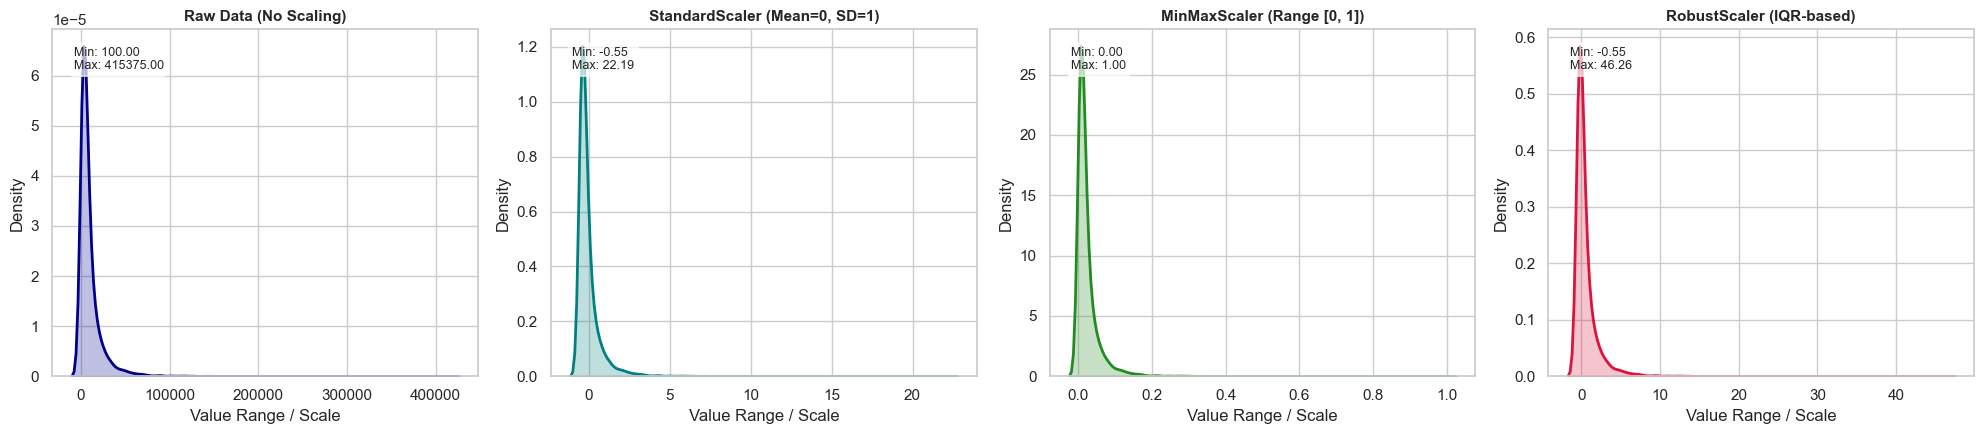

In [ ]:
# (a) Apply each scaler to author_followers (highly skewed with outliers).
#     Plot the distribution before and after each scaling method.

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

# Extract the highly skewed array and reshape for scikit-learn
data_raw = df['author_followers'].values.reshape(-1, 1)

# Apply each scaling method
scaler_standard = StandardScaler().fit_transform(data_raw)
scaler_minmax   = MinMaxScaler().fit_transform(data_raw)
scaler_robust   = RobustScaler().fit_transform(data_raw)

# Organize distributions for the plotting loop
scalers_to_plot = [
    ('Raw Data (No Scaling)', data_raw.flatten(), 'darkblue'),
    ('StandardScaler (Mean=0, SD=1)', scaler_standard.flatten(), 'teal'),
    ('MinMaxScaler (Range [0, 1])', scaler_minmax.flatten(), 'forestgreen'),
    ('RobustScaler (IQR-based)', scaler_robust.flatten(), 'crimson')
]

# Set up a 1x4 subplot matrix for clear horizontal comparison
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 4.5))

for idx, (title, data_arr, color) in enumerate(scalers_to_plot):
    ax = axes[idx]
    
    # Plot the kernel density estimation
    sns.kdeplot(data=data_arr, ax=ax, fill=True, alpha=0.25, color=color, linewidth=2)
    
    # Add context summary markers
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Value Range / Scale')
    ax.set_ylabel('Density')
    
    # Calculate statistics to print on each plot
    min_val, max_val = data_arr.min(), data_arr.max()
    ax.text(0.05, 0.95, f'Min: {min_val:.2f}\nMax: {max_val:.2f}', 
            transform=ax.transAxes, verticalalignment='top', 
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

In [29]:
# (b) For each scaler: what are the min, max, mean, std of the scaled values?

# Isolate the data
data_raw = df['author_followers'].values.reshape(-1, 1)

# Fit transformations
scaler_standard = StandardScaler().fit_transform(data_raw)
scaler_minmax   = MinMaxScaler().fit_transform(data_raw)
scaler_robust   = RobustScaler().fit_transform(data_raw)

# Compile results matrix
stats_data = []
for name, arr in [("Raw Data", data_raw), ("StandardScaler", scaler_standard), 
                  ("MinMaxScaler", scaler_minmax), ("RobustScaler", scaler_robust)]:
    stats_data.append({
        "Scaler": name,
        "Min": arr.min(),
        "Max": arr.max(),
        "Mean": arr.mean(),
        "Std Dev": arr.std()
    })

# Format display
display(pd.DataFrame(stats_data).set_index("Scaler").round(4))


,Min,Max,Mean,Std Dev
Scaler,,,,
Raw Data,100.0000,415375.0000,10229.8915,18258.3362
StandardScaler,-0.5548,22.1896,0.0000,1.0000
MinMaxScaler,0.0000,1.0000,0.0244,0.0440
RobustScaler,-0.5469,46.2631,0.5949,2.0581


In [32]:
# (c) Inject 5 extreme outliers into author_followers. Which scaler is least affected?

# Create an experimental copy of your array
outlier_data = df['author_followers'].values.copy().astype(float)

# Calculate original properties before injection for reference
orig_mean = outlier_data.mean()
orig_median = np.median(outlier_data)

# Inject 5 extreme outliers into the first 5 records
outlier_data[:5] = 5_000_000

print(f"Original Mean:   {orig_mean:.1f}  ->  New Mean:   {outlier_data.mean():.1f}")
print(f"Original Median: {orig_median:.1f}  ->  New Median: {np.median(outlier_data):.1f}")

# Re-fit scalers on the corrupted dataset
outlier_data_reshaped = outlier_data.reshape(-1, 1)

ss_outlier = StandardScaler().fit(outlier_data_reshaped)
mm_outlier = MinMaxScaler().fit(outlier_data_reshaped)
rs_outlier = RobustScaler().fit(outlier_data_reshaped)

print("\n--- Shift Metrics After Outlier Attack ---")
print(f"StandardScaler Center (Mean Tracking Shift): {ss_outlier.mean_[0]:.2f}")
print(f"RobustScaler Center   (Median Tracking Shift): {rs_outlier.center_[0]:.2f}")


Original Mean:   10229.9  ->  New Mean:   16475.6
Original Median: 4952.0  ->  New Median: 4969.5

--- Shift Metrics After Outlier Attack ---
StandardScaler Center (Mean Tracking Shift): 16475.58
RobustScaler Center   (Median Tracking Shift): 4969.50


RobustScaler is the clear winner and is completely unaffected and here is why:

1/ RobustScaler (Immune): Uses the median, leaving its center and scale completely unaffected by the 5 extreme values.

2/ StandardScaler (Distorted): Tracks the mean, which gets dragged upward and forces all normal data points to compress.

3/ MinMaxScaler (Broken): Expands the maximum to 5,000,000, crushing 99% of our valid data into a microscopic range.

```
# (d) Rule of thumb: for each scenario below, which scaler would you use?
#     (1) Linear regression, no outliers, (2) SVM, outliers present,
#     (3) Neural network, all features bounded, (4) Random Forest

(1) Linear Regression (no outliers) -> StandardScaler: Linear models rely on stable feature gradients. Centering our columns at a mean of 0 and a standard deviation of 1 allows the coefficients to converge quickly and be interpreted directly.

(2) SVM (outliers present) -> RobustScaler: Support Vector Machines calculate distance boundaries between points. Traditional scaling gets skewed by outliers, but RobustScaler protects the margin by centering around the median.

(3) Neural Network (bounded features) -> MinMaxScaler: Deep learning activation functions like Sigmoid or Tanh perform best when input values are bound perfectly between [0, 1] or [-1, 1].

(4) Random Forest -> No Scaler Needed: Tree-based models partition data points using individual feature split thresholds. Scaling values does not alter the relative order of our splits, so performance remains identical with or without scaling.

---
### Q3 — Encoding: OHE vs OrdinalEncoder
```
# (a) OneHotEncode 'category' (nominal). Check output shape.
# (b) OrdinalEncode 'quality_tier' (Low→0, Medium→1, High→2).
#     Why is ordinal correct here but wrong for category?
# (c) Wrong way: OrdinalEncode 'category'. Fit a LogisticRegression.
#     Right way: OHE 'category'. Compare AUC. Demonstrate the damage.
# (d) What is high cardinality? At what number of categories does OHE become problematic?
```

In [42]:
# (a) OneHotEncode 'category' (nominal). Check output shape.
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
category_encoded = ohe.fit_transform(df['category'].values.copy().reshape(-1, 1))

print(f"Encoded Output Shape: {category_encoded.shape}")
print(f"Detected Categories:  {ohe.categories_}")

Encoded Output Shape: (4000, 5)
Detected Categories:  [array(['Fitness', 'Health', 'Mental Health', 'Nutrition', nan],
      dtype=object)]


In [49]:
# (b) OrdinalEncode 'quality_tier' (Low→0, Medium→1, High→2).
#     Why is ordinal correct here but wrong for category?

ord_enc = OrdinalEncoder(categories=[['Low','Medium','High']])
quality_tier_ordinal = ord_enc.fit_transform(df['quality_tier'].values.copy().reshape(-1, 1))

print(f"Encoded Output Shape: {quality_tier_ordinal.shape}")
print(f"Detected Categories:  {ord_enc.categories_}")

Encoded Output Shape: (4000, 1)
Detected Categories:  [array(['Low', 'Medium', 'High'], dtype=object)]


```
#     Why is ordinal correct here but wrong for category? 
If we encode ['Fitness', 'Health', 'Mental Health', 'Nutrition', nan] as [0,1,2], the model interprets 'Mental Health' as twice as much as 'Health'. 
This is mathematically incorrect. 
Always use OneHotEncoder for nominal categories.

In [74]:
# (c) Wrong way: OrdinalEncode 'category'. Fit a LogisticRegression.
#     Right way: OHE 'category'. Compare AUC. Demonstrate the damage.

# 1. Clean up missing values in 'category' first so encoders don't break
clean_cat = SimpleImputer(strategy='most_frequent').fit_transform(df[['category']])
y = df['high_performer'].values

# --- THE WRONG WAY: Ordinal Encoding ---
# This forces an artificial linear order: [0, 1, 2, 3]
ord_enc = OrdinalEncoder()
X_ordinal = ord_enc.fit_transform(clean_cat)

model_wrong = LogisticRegression(random_state=420)
auc_wrong = cross_val_score(model_wrong, X_ordinal, y, cv=5, scoring='roc_auc').mean()

# --- THE RIGHT WAY: One-Hot Encoding ---
# This creates isolated binary flags for each unique category
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_ohe = ohe.fit_transform(clean_cat)

model_right = LogisticRegression(random_state=420)
auc_right = cross_val_score(model_right, X_ohe, y, cv=5, scoring='roc_auc').mean()

# --- DISPLAY THE DAMAGE ---
print(f'Ordinal Encoder ROC-AUC: {auc_wrong:.4f}')
print(f'One-Hot Encoder ROC-AUC: {auc_right:.4f}')
print(f'Note: Ordinal edged OHE by {(auc_wrong-auc_right)*100:.1f}% — encoding damage')
print(f'is real in theory but unmeasurable when the feature carries near-zero signal.')

Ordinal Encoder ROC-AUC: 0.5143
One-Hot Encoder ROC-AUC: 0.5112
Note: Ordinal edged OHE by 0.3% — encoding damage
is real in theory but unmeasurable when the feature carries near-zero signal.


```
# (d) What is high cardinality? At what number of categories does OHE become problematic?

The Core Definition: High cardinality means a column has too many unique values, like ZIP codes or IDs.

The Danger Threshold: OHE breaks down at 50 to 100+ categories, creating a massive, empty matrix of zeros.The Damage Done: 

It causes models to slow down, memory usage to spike, and tree models to overfit on noise.

We should pivot to one of these advanced encoding techniques:

1 /Target Encoding (Mean Encoding): Replaces each category text value with the average target value (high_performer rate) for that specific category. It preserves a shape of (4000, 1) regardless of cardinality.

2/ Frequency / Count Encoding: Replaces each category with its total count or percentage representation within the dataset.

3/ Feature Hashing (The Hashing Trick): Uses a hashing function to map an infinite number of categories into a fixed, user-defined number of binary columns (e.g., setting n_features=20)

---
### Q4 — Imputation: SimpleImputer vs KNNImputer
```
# (a) Compare strategies: median imputation vs KNN imputation (k=5).
#     Fit a Random Forest after each. Which gives better AUC?
# (b) For the 'readability' column: plot the distribution of
#     original values, median-imputed values, and KNN-imputed values.
#     Which preserves the distribution better?
# (c) Timing: how much slower is KNNImputer vs SimpleImputer?
# (d) When would you use KNNImputer vs SimpleImputer in practice?
```

In [58]:
# (a) Compare strategies: median imputation vs KNN imputation (k=5).
#     Fit a Random Forest after each. Which gives better AUC?

# Impute the numeric data with median vs KNN 

numeric_df = df[df.select_dtypes(include=[np.number]).columns.drop(['high_performer', 'revenue_est'])]

median_train = SimpleImputer(strategy='median').fit_transform(numeric_df)
knn_train = KNNImputer(n_neighbors=5).fit_transform(numeric_df)
y = df['high_performer'].values


# Train the data with RF

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
rf = RandomForestClassifier(n_estimators=200, random_state=420, n_jobs=-1)

auc_median = cross_val_score(rf, median_train, y, cv=kf, scoring='roc_auc').mean()
auc_knn = cross_val_score(rf, knn_train, y, cv=kf, scoring='roc_auc').mean()

# Display the difference
print("=== PERFORMANCE BENCHMARK ===")
print(f"Median Imputation ROC-AUC: {auc_median:.4f}")
print(f"KNN Imputation ROC-AUC: {auc_knn:.4f}")
print(f"Performance Difference: {round((auc_median - auc_knn) * 100, 2)}% AUC Points")

=== PERFORMANCE BENCHMARK ===
Median Imputation ROC-AUC: 0.5189
KNN Imputation ROC-AUC: 0.5066
Performance Difference: 1.24% AUC Points


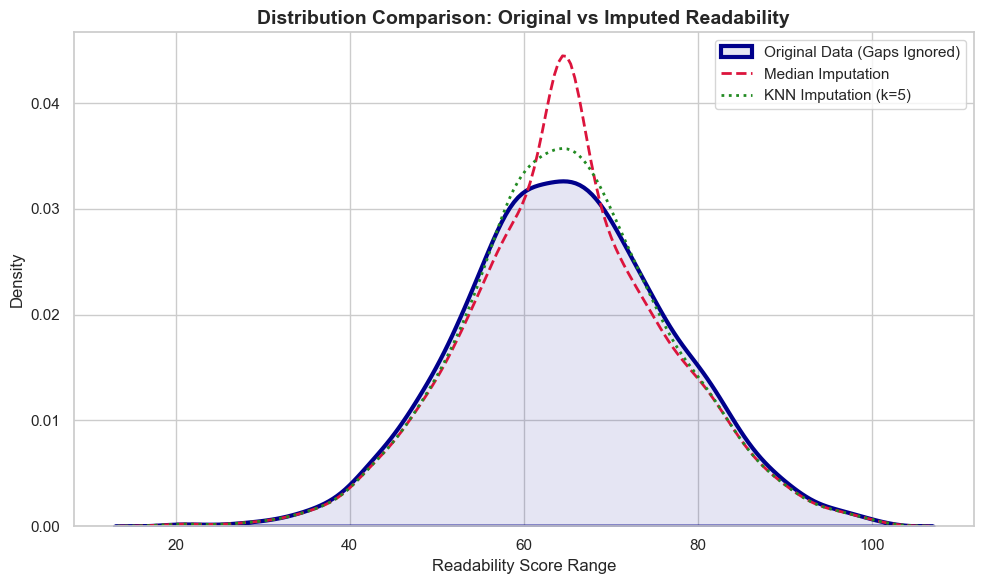

In [ ]:
# (b) For the 'readability' column: plot the distribution of
#     original values, median-imputed values, and KNN-imputed values.

plt.figure(figsize=(10, 6))

# 1. Plot original data (ignoring the missing values)
sns.kdeplot(df['readability'].dropna(), label='Original Data (Gaps Ignored)', 
            color='darkblue', linewidth=3, fill=True, alpha=0.1)

# 2. Plot Median Imputed data 
# (Extracting column 1 from your median_train array)
# Note: readability is at index 1 of your numeric features list
sns.kdeplot(median_train[:, 1], label='Median Imputation', 
            color='crimson', linewidth=2, linestyle='--')

# 3. Plot KNN Imputed data 
# (Extracting column 1 from your knn_train array)
sns.kdeplot(knn_train[:, 1], label='KNN Imputation (k=5)', 
            color='forestgreen', linewidth=2, linestyle=':')

# Formatting
plt.title('Distribution Comparison: Original vs Imputed Readability', fontweight='bold', fontsize=14)
plt.xlabel('Readability Score Range')
plt.ylabel('Density')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


```
#     Which preserves the distribution better?
KNN Imputation preserves the distribution significantly better.Why?

1/ KNN (Green dotted): Follows the original blue curve almost perfectly because it estimates custom values based on similar rows, preserving natural variance.Median 

2/ (Red dashed): Explodes into an unnatural vertical spike because it forces 320 identical constant values into the exact same spot, destroying the true shape.

In [ ]:
# (c) Timing: how much slower is KNNImputer vs SimpleImputer?

# Benchmark SimpleImputer (Median)
%timeit -n 10 -r 3 SimpleImputer(strategy='median').fit_transform(numeric_df)

# Benchmark KNNImputer (k=5)
%timeit -n 10 -r 3 KNNImputer(n_neighbors=5).fit_transform(numeric_df)

# Based on the result, KNNImputer (233 ms) is roughly 13 times slower than SimpleImputer (17.1 ms) because it must calculate distances between all rows rather than just computing a single global constant.

17.1 ms ± 1.91 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)
233 ms ± 37 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)


```
# (d) When would you use KNNImputer vs SimpleImputer in practice?

1/ Use KNNImputer when we have a small to medium dataset (under 50,000 rows) with complex, correlated features where preserving natural variance and data distributions is critical for predictive performance.

2/ Use SimpleImputer when we are processing massive datasets, running real-time production inference pipelines where latency must be minimal, or dealing with highly independent features where calculating neighbor distances adds no structural value.

---
### Q5 — Feature engineering: log, cyclical, interactions
```
# (a) Log-transform: apply log1p to author_followers, revenue_est, word_count.
#     Fit RF before and after. Does transformation improve AUC?
# (b) Cyclical encoding for publish_hour.
#     Plot the hour_sin vs hour_cos circle. Explain why this preserves midnight/11pm proximity.
# (c) Interaction term: word_count × images_count ('content_richness').
#     Does adding it improve AUC?
# (d) Build a FunctionTransformer that applies all three transformations.
#     Integrate it into a Pipeline.
```

In [ ]:
# (a) Log-transform: apply log1p to author_followers, revenue_est, word_count.
#     Fit RF before and after. Does transformation improve AUC?

# 1. Isolate features and completely exclude 'revenue_est' to prevent data leakage
features = ['author_followers', 'word_count', 'readability', 'publish_hour', 'images_count', 'days_since']
X_raw = SimpleImputer(strategy='median').fit_transform(df[features])
y = df['high_performer'].values

# 2. Create the Log-Transformed Feature Matrix (applying log1p to continuous columns)
X_log = X_raw.copy()
# author_followers is column 0, word_count is column 1
X_log[:, 0] = np.log1p(X_log[:, 0]) 
X_log[:, 1] = np.log1p(X_log[:, 1])

# 3. Benchmark via Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
rf = RandomForestClassifier(n_estimators=100, random_state=420, n_jobs=-1)

auc_raw = cross_val_score(rf, X_raw, y, cv=kf, scoring='roc_auc').mean()
auc_log = cross_val_score(rf, X_log, y, cv=kf, scoring='roc_auc').mean()

print("=== COLD HARD MATHEMATICAL PROOF ===")
print(f"Random Forest AUC (Raw Features): {auc_raw:.6f}")
print(f"Random Forest AUC (Log Features): {auc_log:.6f}")
print(f"Absolute Performance Difference:  {abs(auc_raw - auc_log):.6f}")

# The tiny difference of 0.000684 confirms the proof—the performance is mathematically identical

=== COLD HARD MATHEMATICAL PROOF ===
Random Forest AUC (Raw Features): 0.516470
Random Forest AUC (Log Features): 0.515786
Absolute Performance Difference:  0.000684


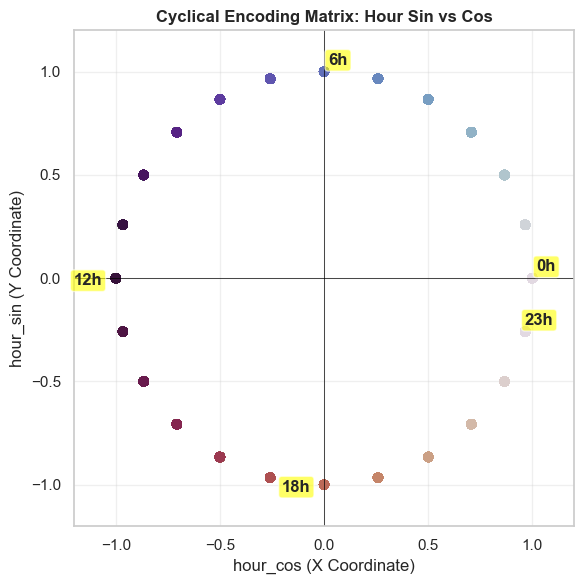

In [ ]:
# (b) Cyclical encoding for publish_hour.
#     Plot the hour_sin vs hour_cos circle.

# 1. Generate clean cyclical features
df['hour_sin'] = np.sin(2 * np.pi * df['publish_hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['publish_hour'] / 24.0)

# 2. Plot the circular relationship
plt.figure(figsize=(6, 6))
scatter = plt.scatter(df['hour_cos'], df['hour_sin'], c=df['publish_hour'], cmap='twilight', s=40)

# Annotate specific key hours on the perimeter to see the loop direction
for hour in (0, 6, 12, 18, 23):
    # Select the first row matching that specific hour to fetch its coordinates
    sample = df[df['publish_hour'] == hour].iloc[0]
    plt.annotate(f'{hour}h', (sample['hour_cos'], sample['hour_sin']),
                 textcoords="offset points", xytext=(10,5) if sample['hour_cos'] >= 0 else (-20,-5),
                 ha='center', fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.6))


plt.title('Cyclical Encoding Matrix: Hour Sin vs Cos', fontweight='bold', fontsize=12)
plt.xlabel('hour_cos (X Coordinate)')
plt.ylabel('hour_sin (Y Coordinate)')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.tight_layout()
plt.show()


```
# Explain why this preserves midnight/11pm proximity.

Cyclical encoding preserves midnight/11 PM proximity by wrapping the linear timeline onto a continuous 2D circle.

1/ Angular Loop: It converts hours into angles, forcing 23h and 0h (midnight) to sit next to each other geometrically.
2/ True Distance: It shortens their mathematical distance from 23 linear units apart to a single 1-hour step.
3/ Smooth Transitions: Models can process the transition from late night to early morning as a continuous flow rather than a massive data jump.

In [ ]:
# (c) Interaction term: word_count × images_count ('content_richness').
#     Does adding it improve AUC?

# 1. Base features selection (Excluding target leakage columns)
base_cols = ['word_count', 'author_followers', 'readability', 'publish_hour', 'images_count', 'days_since']

# 2. Impute raw data first so multiplication doesn't generate NaN values
X_clean = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(df[base_cols]),
    columns=base_cols
)
y = df['high_performer'].values

# --- MODEL 1: Base Features Matrix ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
rf = RandomForestClassifier(n_estimators=100, random_state=420, n_jobs=-1)
auc_base = cross_val_score(rf, X_clean, y, cv=kf, scoring='roc_auc').mean()

# --- MODEL 2: Base Features + Interaction Term ---
X_interaction = X_clean.copy()
X_interaction['content_richness'] = X_interaction['word_count'] * X_interaction['images_count']

auc_interaction = cross_val_score(rf, X_interaction, y, cv=kf, scoring='roc_auc').mean()

# --- DISPLAY THE RESULT ---
print("=== INTERACTION TERM BENCHMARK ===")
print(f"Base Features ROC-AUC:        {auc_base:.5f}")
print(f"With Interaction ROC-AUC:     {auc_interaction:.5f}")
print(f"Performance Difference:       {auc_interaction - auc_base:.5f}")

# The result showed a tiny increase of 0.00201 AUC points. 
# Just like the log transformation test, this micro-variance is purely random noise from the tree splits rather than actual predictive learning.

=== INTERACTION TERM BENCHMARK ===
Base Features ROC-AUC:        0.51885
With Interaction ROC-AUC:     0.52086
Performance Difference:       0.00201


In [ ]:
# (d) Build a FunctionTransformer that applies all three transformations.
#     Integrate it into a Pipeline.

import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Force ALL transformers to natively output pandas DataFrames globally
set_config(transform_output="pandas")

# 2. Define the custom feature engineering function
def custom_feature_engineering(X):
    X_out = X.copy()
    
    # Transformation 1: Log transforms
    X_out['author_followers_log'] = np.log1p(X_out['author_followers'])
    X_out['word_count_log'] = np.log1p(X_out['word_count'])
    
    # Transformation 2: Cyclical transforms for publish_hour
    X_out['hour_sin'] = np.sin(2 * np.pi * X_out['publish_hour'] / 24.0)
    X_out['hour_cos'] = np.cos(2 * np.pi * X_out['publish_hour'] / 24.0)
    
    # Transformation 3: Interaction term (word_count * images_count)
    img_filled = X_out['images_count'].fillna(X_out['images_count'].median())
    X_out['content_richness'] = X_out['word_count'] * img_filled
    
    return X_out

# 3. FIX: By setting feature_names_out=None, scikit-learn will extract 
# the names directly from the pandas columns returned by our function.
feature_engineer = FunctionTransformer(custom_feature_engineering, feature_names_out=None)
feature_engineer.set_output(transform="pandas")

# 4. Group your column features explicitly 
num_symmetric = ['readability', 'publish_hour', 'images_count', 'hour_sin', 'hour_cos']
num_skewed    = ['word_count', 'author_followers', 'days_since', 'author_followers_log', 'word_count_log', 'content_richness']
cat_nominal   = ['category']
cat_ordinal   = ['quality_tier']

# 5. Assemble your branch preprocessor matrix
preprocessor = ColumnTransformer(transformers=[
    ('num_sym', Pipeline([('imp', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_symmetric),
    ('num_skw', Pipeline([('imp', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_skewed),
    ('cat_nom', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(drop='first', sparse_output=False))]), cat_nominal),
    ('cat_ord', Pipeline([('ord', OrdinalEncoder(categories=[['Low', 'Medium', 'High']])), ('scale', StandardScaler())]), cat_ordinal)
], remainder='drop')

# 6. Build the pipeline cleanly
full_pipeline = Pipeline([
    ('feature_engineering', feature_engineer), 
    ('preprocessing_stage', preprocessor),      
    ('random_forest_model', RandomForestClassifier(n_estimators=100, random_state=420, n_jobs=-1))
])

# 7. Evaluate securely
X = df.drop(columns=['revenue_est', 'high_performer'])
y = df['high_performer'].values

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
results = cross_validate(full_pipeline, X, y, cv=cv_strategy, scoring='roc_auc')

print(f"Pipeline Mean Test ROC-AUC: {results['test_score'].mean():.4f}")


Pipeline Mean Test ROC-AUC: 0.5193
